# MLP Deep Learning Model

In [29]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [30]:
df = pd.read_csv("../data/processed/cicids2017_clean.csv")
print(df.shape)

(2520798, 70)


In [31]:
label_encoder = LabelEncoder()

df["Label_encoded"] = label_encoder.fit_transform(df["Label"])

In [32]:
def validate_dataset(df):

    print("=" * 50)
    print("DATASET VALIDATION")
    print("=" * 50)

    # Required columns
    assert "Label" in df.columns, \
        "Label column is missing."

    assert "Label_encoded" in df.columns, \
        "Label_encoded column is missing."

    # Missing values
    assert df.isnull().sum().sum() == 0, \
        "Missing values detected."

    # Infinite values (numeric columns only)
    numeric = df.select_dtypes(include=[np.number])

    assert np.isinf(numeric).sum().sum() == 0, \
        "Infinite values detected."

    # Duplicate rows
    assert df.duplicated().sum() == 0, \
        "Duplicate rows detected."

    # Label encoding consistency
    assert df["Label"].nunique() == df["Label_encoded"].nunique(), \
        "Mismatch between Label and Label_encoded."

    # Display information
    print(f"Shape              : {df.shape}")
    print(f"Number of classes  : {df['Label'].nunique()}")

    print("\nClass distribution:")
    print(df["Label"].value_counts())

    print("\nDataset validation passed.")
validate_dataset(df)


DATASET VALIDATION
Shape              : (2520798, 71)
Number of classes  : 15

Class distribution:
Label
BENIGN                        2095057
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Dataset validation passed.


In [33]:
X = df.drop(columns=["Label", "Label_encoded"])

y = df["Label_encoded"]

In [34]:
# Verify no target leakage
assert "Label" not in X.columns
assert "Label_encoded" not in X.columns

print("No target leakage detected.")

No target leakage detected.


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

Training set : (2016638, 69)
Testing set  : (504160, 69)


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(len(label_encoder.classes_), activation="softmax")
])

In [38]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,791 (77.31 KB)

 Trainable params: 19,791 (77.31 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [41]:
start_train = time.time()

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

train_time = time.time() - start_train

Epoch 1/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.9628 - loss: 0.1126 - val_accuracy: 0.9795 - val_loss: 0.0515
Epoch 2/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9760 - loss: 0.0576 - val_accuracy: 0.9799 - val_loss: 0.0449
Epoch 3/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9783 - loss: 0.0505 - val_accuracy: 0.9796 - val_loss: 0.0413
Epoch 4/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9797 - loss: 0.0471 - val_accuracy: 0.9832 - val_loss: 0.0379
Epoch 5/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9809 - loss: 0.0444 - val_accuracy: 0.9821 - val_loss: 0.0404
Epoch 6/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9818 - loss: 0.0425 - val_accuracy: 0.9850 - val_loss: 0.0340
Epoch 7/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9824 - loss: 0.0415 - val_accuracy: 0.9858 - val_loss: 0.0332
Epoch 8/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9828 - loss: 0

In [42]:
start_pred = time.time()

probabilities = model.predict(X_test_scaled)

prediction_time = time.time() - start_pred

y_pred = np.argmax(probabilities, axis=1)

15755/15755 ━━━━━━━━━━━━━━━━━━━━ 16s 1ms/step


In [43]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

In [44]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

                            precision    recall  f1-score   support

                    BENIGN       0.99      1.00      0.99    419012
                       Bot       0.97      0.34      0.51       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.98      0.98      0.98      2057
                  DoS Hulk       0.98      0.99      0.98     34569
          DoS Slowhttptest       0.88      0.98      0.93      1046
             DoS slowloris       0.97      0.95      0.96      1077
               FTP-Patator       0.96      0.99      0.98      1186
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       0.50      0.29      0.36         7
                  PortScan       0.95      0.91      0.93     18139
               SSH-Patator       1.00      0.90      0.95       644
  Web Attack � Brute Force       0.80      0.04      0.08       294
Web Attack � Sql Injection       0.00      0.00

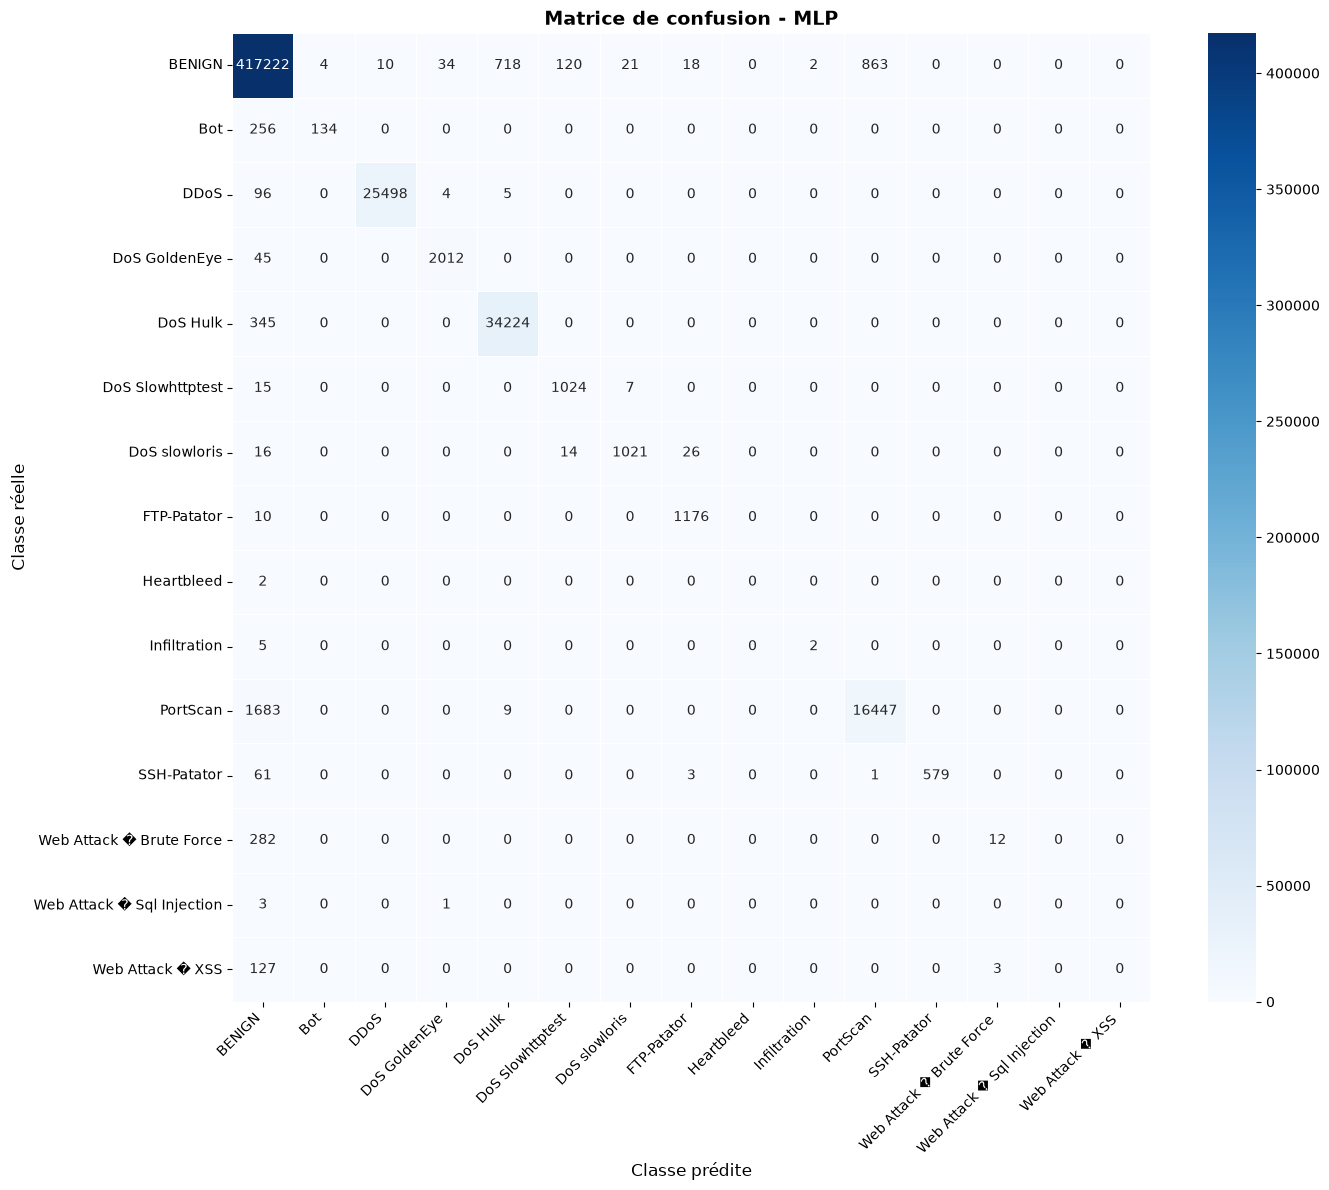

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5,
    cbar=True
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.xlabel("Classe prédite", fontsize=12)
plt.ylabel("Classe réelle", fontsize=12)
plt.title("Matrice de confusion - MLP", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [46]:
model.save("../models/mlp.keras")

In [47]:
joblib.dump(
    scaler,
    "../models/mlp_scaler.pkl"
)

['../models/mlp_scaler.pkl']

Class Weights with MLP 

Idea : Mistakes on rare classes should be penalized more

In [74]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert to dictionary
class_weights = dict(zip(classes, weights))

# Cap the maximum weight
MAX_WEIGHT = 15

class_weights = {
    cls: min(weight, MAX_WEIGHT)
    for cls, weight in class_weights.items()
}

print(class_weights)

{np.int64(0): np.float64(0.08021415495009582), np.int64(1): 15, np.int64(2): np.float64(1.3127743439018595), np.int64(3): 15, np.int64(4): np.float64(0.9722696712637194), np.int64(5): 15, np.int64(6): 15, np.int64(7): 15, np.int64(8): 15, np.int64(9): 15, np.int64(10): np.float64(1.852974065651345), np.int64(11): 15, np.int64(12): 15, np.int64(13): 15, np.int64(14): 15}


In [75]:
model_weighted = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(len(label_encoder.classes_), activation="softmax")
])

In [76]:
model_weighted.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [77]:
start_train = time.time()
history_weighted = model_weighted.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)
end_train = time.time() - start_train
train_time_weighted = end_train - start_train

Epoch 1/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.8448 - loss: 0.1755 - val_accuracy: 0.8907 - val_loss: 0.2864
Epoch 2/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9010 - loss: 0.0806 - val_accuracy: 0.9319 - val_loss: 0.2169
Epoch 3/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9095 - loss: 0.0686 - val_accuracy: 0.9217 - val_loss: 0.2131
Epoch 4/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9173 - loss: 0.0619 - val_accuracy: 0.9316 - val_loss: 0.1773
Epoch 5/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9219 - loss: 0.0566 - val_accuracy: 0.9302 - val_loss: 0.1848
Epoch 6/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9241 - loss: 0.0546 - val_accuracy: 0.9345 - val_loss: 0.1804
Epoch 7/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9280 - loss: 0.0524 - val_accuracy: 0.9397 - val_loss: 0.1593
Epoch 8/30
3151/3151 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9301 - loss: 0

In [78]:
start_pred = time.time()

y_prob_weighted = model_weighted.predict(X_test_scaled)

prediction_time_weighted = time.time() - start_pred

y_pred_weighted = np.argmax(y_prob_weighted, axis=1)

15755/15755 ━━━━━━━━━━━━━━━━━━━━ 14s 869us/step


In [79]:
accuracy_weighted = accuracy_score(y_test, y_pred_weighted)

precision_weighted = precision_score(
    y_test,
    y_pred_weighted,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test,
    y_pred_weighted,
    average="weighted",
    zero_division=0
)

weighted_f1_weighted = f1_score(
    y_test,
    y_pred_weighted,
    average="weighted",
    zero_division=0
)

macro_f1_weighted = f1_score(
    y_test,
    y_pred_weighted,
    average="macro",
    zero_division=0
)

In [80]:
print(f"Accuracy       : {accuracy_weighted:.6f}")
print(f"Precision      : {precision_weighted:.6f}")
print(f"Recall         : {recall_weighted:.6f}")
print(f"Weighted F1    : {weighted_f1_weighted:.6f}")
print(f"Macro F1       : {macro_f1_weighted:.6f}")
print(f"Training Time  : {train_time_weighted:.2f} sec")
print(f"Prediction Time: {prediction_time_weighted:.2f} sec")

Accuracy       : 0.957075
Precision      : 0.974171
Recall         : 0.957075
Weighted F1    : 0.963148
Macro F1       : 0.595039
Training Time  : -1784796643.97 sec
Prediction Time: 19.27 sec


In [81]:
print("=" * 60)
print("MLP WITH CLASS WEIGHTS")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred_weighted,
    target_names=label_encoder.classes_,
    zero_division=0
))

MLP WITH CLASS WEIGHTS
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.95      0.97    419012
                       Bot       0.09      0.90      0.16       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.72      1.00      0.84      2057
                  DoS Hulk       0.83      1.00      0.91     34569
          DoS Slowhttptest       0.77      0.99      0.87      1046
             DoS slowloris       0.83      0.98      0.90      1077
               FTP-Patator       0.88      0.99      0.93      1186
                Heartbleed       0.50      0.50      0.50         2
              Infiltration       0.04      0.86      0.08         7
                  PortScan       0.73      1.00      0.84     18139
               SSH-Patator       0.52      0.97      0.68       644
  Web Attack � Brute Force       0.12      0.90      0.21       294
Web Attack � Sql Injecti

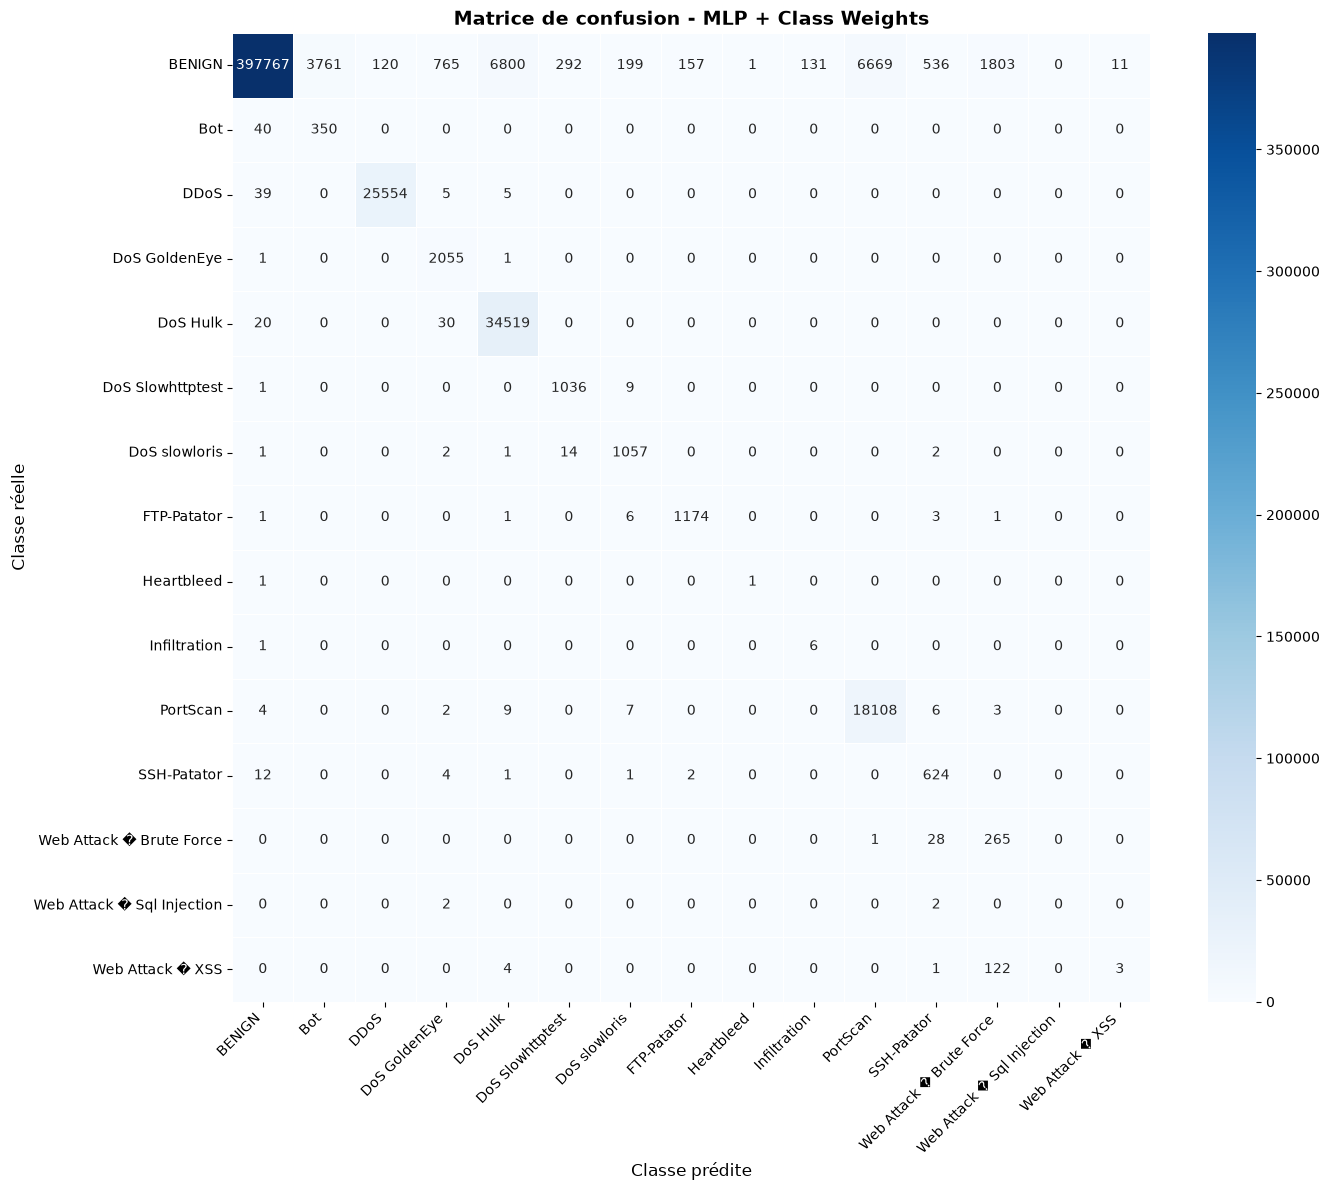

In [82]:
cm = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    linewidths=0.5,
    cbar=True
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.xlabel("Classe prédite", fontsize=12)
plt.ylabel("Classe réelle", fontsize=12)
plt.title("Matrice de confusion - MLP + Class Weights", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [83]:
comparison = pd.DataFrame([
    {
        "Model": "MLP",
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    },
    {
        "Model": "MLP + Class Weights",
        "Accuracy": accuracy_weighted,
        "Macro F1": macro_f1_weighted
    }
])

comparison

,Model,Accuracy,Macro F1
0,MLP,0.990461,0.643057
1,MLP + Class Weights,0.957075,0.595039
